### Import of important libraries ###

In [83]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math

In [84]:
printing = True #Set to true to print everything
plotting = True

### Usefull formulas ###

In [85]:
def inches(meters):
    return 1/0.0254 * meters

def meters(inches):
    return 0.0254 * inches

def weight(density, length, diameter, thickness):
    return 9.81 * density * meters(length) * np.pi * meters(diameter) * meters(thickness)/1000

def buoyancy(density, length, diameter, thickness):
    return 9.81 * density *np.pi/4 * (meters(diameter) + meters(thickness))**2 * meters(length)/1000

def length(x1, x2, y1=0, y2=0, z1=0, z2=0): #gives the length for 1D, 2D or 3D
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

def norm_type(t: str) -> str:
    s = str(t).strip().upper()
    if s in ("LEG", "L"):
        return "Leg"
    if s == "H":
        return "H"
    if s == "K":
        return "K"
    return s

def parse_nodes_connected(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    m = re.fullmatch(r"\s*(\d+)\s*-\s*(\d+)\s*", s)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

# Calculate the equivalant beam
def equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E):
    h_i = np.asarray(h_i, dtype=float)
    I_top_i = np.asarray(I_top_i, dtype=float)
    I_bottom_i = np.asarray(I_bottom_i, dtype=float)

    if not (len(h_i) == len(I_top_i) == len(I_bottom_i)):
        raise ValueError("h_i, I_top_i, I_bottom_i must have same length")
    if np.any(h_i <= 0):
        raise ValueError("All h_i must be > 0")

    I_mean_i = 0.5 * (I_top_i + I_bottom_i)
    m_i = (M_legs_total + M_bracing_total) / h_i
    m_eq = np.sum(m_i * h_i) / np.sum(h_i)
    EI_eq = E * (np.sum(I_mean_i * h_i) / np.sum(h_i))

    return m_i, I_mean_i, m_eq, EI_eq

# Function for the first natural frequency, based on the memo
def first_frequency_cantilever(EI, m, L, Mtop):
    """
    EI    : N·m^2
    m     : kg/m
    L     : m
    Mtop  : kg
    """    
    f1 = (1.0 / (2.0 * np.pi)) * np.sqrt((3.04 * EI) / (((0.227 * m * L) + Mtop) * (L ** 3)))
    return f1


def section_inertia_from_leg_layout(z_level, nodes_3d, leg_node_ids, A_leg_m2):
    # Nodes at this elevation
    pts = [(nodes_3d[n][0], nodes_3d[n][1]) for n in leg_node_ids if np.isclose(nodes_3d[n][2], z_level)]
    if len(pts) < 3:
        raise ValueError(f"Not enough leg nodes at z={z_level} to build section inertia")

    x = np.array([p[0] for p in pts], dtype=float)
    y = np.array([p[1] for p in pts], dtype=float)
    x_c, y_c = np.mean(x), np.mean(y)

    # Using cross-section areas and steiner
    I_x = np.sum(A_leg_m2 * (y - y_c) ** 2)
    I_y = np.sum(A_leg_m2 * (x - x_c) ** 2)
    return 0.5 * (I_x + I_y)

### Import configuration ###

In [86]:
file_path = "Data.xlsx"
geom_df = pd.read_excel(file_path, sheet_name="Geometry")
conn_df = pd.read_excel(file_path, sheet_name="Members")


# Read 3D nodes
node_df = geom_df[
    geom_df["Nodes"].notna() &
    geom_df["X"].notna() &
    geom_df["Y"].notna() &
    geom_df["Z"].notna()
].copy()

nodes_3d = {
    int(row["Nodes"]): (float(row["X"]), float(row["Y"]), float(row["Z"]))
    for _, row in node_df.iterrows()
}


# Read members
elem_df = conn_df[conn_df["Members"].notna()].copy()
elements = []

for _, row in elem_df.iterrows():
    elem_id = int(row["Members"])
    elem_type = str(row["Element type"]).strip()      
    parsed = parse_nodes_connected(row["Connectivity"])  

    if parsed is None:
        continue

    n1, n2 = parsed
    if n1 not in nodes_3d or n2 not in nodes_3d:
        continue

    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]

    elements.append({
        "id": elem_id,
        "type": elem_type,
        "nodes": (n1, n2),
        "length": round(float(length(x1, x2, y1, y2, z1, z2)), 3),
        "coordinates" : [x1, x2, y1, y2, z1, z2]
    })

# use the total length of the legs, instead of each separate segment
leg_indices = [i for i, e in enumerate(elements) if norm_type(e["type"]) == "Leg"]

if len(leg_indices) % 5 != 0:
    raise ValueError(f"Leg segment count must be multiple of 5, found {len(leg_indices)}")

for g in range(0, 4):
    idx_group = leg_indices[g:g+5]

    first_elem = elements[idx_group[0]]
    last_elem = elements[idx_group[-1]]

    n_start = first_elem["nodes"][0]
    n_end = last_elem["nodes"][1]

    x1, y1, z1 = nodes_3d[n_start]
    x2, y2, z2 = nodes_3d[n_end]
    full_leg_length = length(x1, x2, y1, y2, z1, z2)
    
    elements[idx_group[0]]["coordinates"] = [x1, x2, y1, y2, z1, z2]
    elements[idx_group[0]]["length"] = round(float(full_leg_length), 3)
    elements[idx_group[0]]["nodes"] = (n_start, n_end)
    for k in idx_group[1:]:
        elements.pop(idx_group[1])

### Calculate all properties ###

In [87]:
# Build table ONCE from computed elements
df = pd.DataFrame(elements).rename(columns={
    "id": "Number",
    "type": "Element type",
    "length": "L_m",
})

# i want the last 4 H and K pairs seen in file"
df["read_order"] = np.arange(len(df))

# Normalize element types
df["Element type"] = (
    df["Element type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "H": "H",
        "K": "K",
        "LEG": "Leg",
        "L": "Leg"
    })
)

# Numeric safety
df["Number"] = pd.to_numeric(df["Number"], errors="coerce")
df["L_m"] = pd.to_numeric(df["L_m"], errors="coerce")
df["L_eff_m"] = df["L_m"]

gamma_s = 7850.0  # kg/m^3
x = {"H": 0.023, "K": 0.029, "Leg": 0.035}
d_over_t = {"H": 40.0, "K": 40.0, "Leg": 60.0}
E = 210e9  # Pa

# Diameter
df["D_m"] = df["L_eff_m"] * df["Element type"].map(x)
df["D(inches)"] = inches(df["D_m"])
df["Chosen diameter (inches)"] = np.ceil(df["D(inches)"] / 2.0) * 2.0

# Base D/t and the last 4 H/K in file-read order are /25
df["D_over_t"] = df["Element type"].map(d_over_t)
hk_last4_idx = (
    df.loc[df["Element type"].isin(["H", "K"])]
      .sort_values("read_order")
      .tail(4)
      .index
)
df.loc[hk_last4_idx, "D_over_t"] = 25.0

# Thickness
df["Thickness(inches)"] = df["D(inches)"] / df["D_over_t"]
df["Chosen thickness (inches)"] = np.ceil(df["Thickness(inches)"] / 0.125) * 0.125

# all legs chosen thickness
df.loc[df["Element type"].eq("Leg"), "Chosen thickness (inches)"] = 1.5

# Section properties
D = df["Chosen diameter (inches)"]
t = df["Chosen thickness (inches)"]
df["Cross section area (inch2)"] = math.pi * D * t
df["Inertia (inch4)"] = (math.pi / 4.0) * (D ** 3) * t
A_m2 = meters(meters(df["Cross section area (inch2)"]))
df["Weight (kN)"] = weight(7850, inches(df["L_eff_m"]), D, t)
#calculate buoyancy
for i, elem in enumerate(elements[0:24]):
    eq_length = elem["length"]
    df["Buoyancy"] = buoyancy(1025, eq_length, D[i], t[i])

df.loc[28:, "Buoyancy"] =np.ones(4)* buoyancy(1025, inches(df["L_eff_m"][31]), D[31], t[31]) - buoyancy(1025, inches(df["L_eff_m"][31]), D[31]-2*t[31], t[31])
df["Mass (t)"] = (A_m2 * df["L_eff_m"] * gamma_s) / 1000.0

# Output sorted by member number
out = df.sort_values("Number").reset_index(drop=True)
if printing == True:
    print(out[[
        "Number", "Element type", "L_m", "L_eff_m",
        "Chosen diameter (inches)", "Chosen thickness (inches)",
        "Cross section area (inch2)", "Mass (t)", "Inertia (inch4)"
    ]].round(3))

# total masses and weight [kg]
M_legs_total = out.loc[out["Element type"].eq("Leg"), "Mass (t)"].sum() * 1000.0
M_bracing_total = out.loc[out["Element type"].isin(["H", "K"]), "Mass (t)"].sum() * 1000.0
F_legs_total = out.loc[out["Element type"].eq("Leg"), "Weight (kN)"].sum()
F_bracing_total = out.loc[out["Element type"].isin(["H", "K"]), "Weight (kN)"].sum()
F_Buoyancy_total = out["Buoyancy"].sum()
In_Place_weight = F_legs_total + F_bracing_total - F_Buoyancy_total                       

if printing:
    print("\nEquivalent beam results:")
    print(f"M_legs_total [kg]    = {M_legs_total:,.2f}")
    print(f"M_bracing_total [kg] = {M_bracing_total:,.2f}")
    print(f"F_legs_total [kN] = {F_legs_total:,.2f}")
    print(f"F_bracing_toal [kN] = {F_bracing_total:.2f}")
    print(f"F_buoyancy_toal [kN] = {F_Buoyancy_total:.2f}")
    print(f"In_Place_weight [kN] = {In_Place_weight:.2f}")

    Number Element type     L_m  L_eff_m  Chosen diameter (inches)  \
0        1            H  25.530   25.530                      24.0   
1        2            H  25.530   25.530                      24.0   
2        3            H  25.530   25.530                      24.0   
3        4            H  25.530   25.530                      24.0   
4        5            K  34.271   34.271                      40.0   
5        6            K  34.271   34.271                      40.0   
6        7            K  34.271   34.271                      40.0   
7        8            K  34.271   34.271                      40.0   
8        9            H  20.386   20.386                      20.0   
9       10            H  20.386   20.386                      20.0   
10      11            H  20.386   20.386                      20.0   
11      12            H  20.386   20.386                      20.0   
12      13            K  27.325   27.325                      32.0   
13      14          

### Plot structure ###

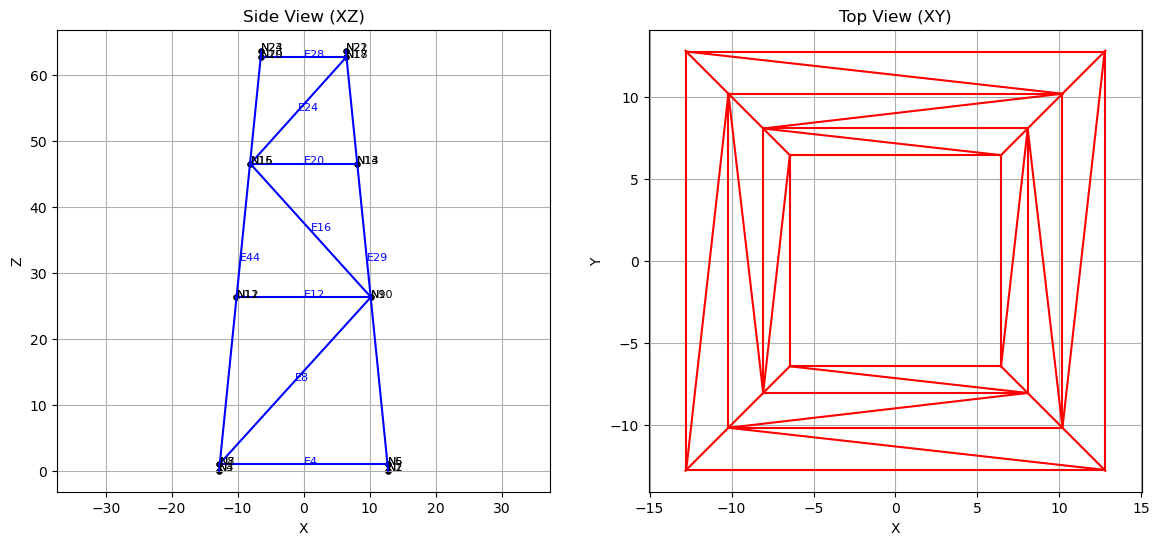

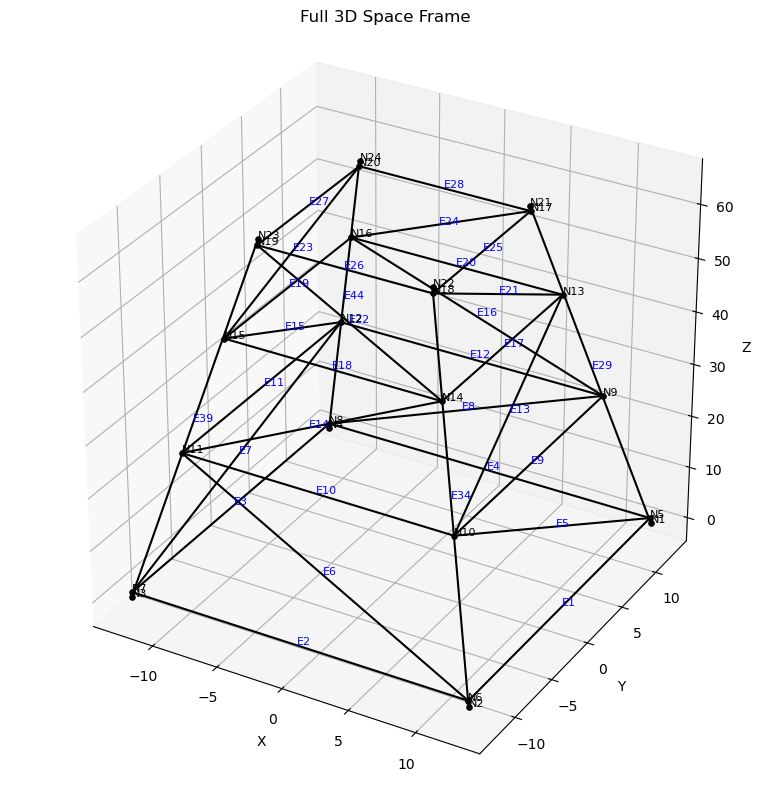

In [88]:
# Plot side and top views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# side view (XZ)
ax1.set_title("Side View (XZ)")
ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.axis("equal")
ax1.grid(True)

for elem in elements:
    if nodes_3d[elem["nodes"][0]][1] > 0 and nodes_3d[elem["nodes"][1]][1] > 0: #print only quarter of the structure
        n1, n2 = elem["nodes"]
        x1, y1, z1 = nodes_3d[n1]
        x2, y2, z2 = nodes_3d[n2]
        ax1.plot([x1, x2], [z1, z2], "b")
        xm, zm = (x1 + x2) / 2.0, (z1 + z2) / 2.0
        ax1.text(xm, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    ax1.scatter(x, z, c="black", s=12)
    ax1.text(x, z, f"N{nid}", color="black", fontsize=8)

# Top view (XY)
ax2.set_title("Top View (XY)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.axis("equal")
ax2.grid(True)

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax2.plot([x1, x2], [y1, y2], "r")

# Plot 3D view
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection="3d")

ax3d.set_title("Full 3D Space Frame")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax3d.plot([x1, x2], [y1, y2], [z1, z2], "k")

    # element label
    xm, ym, zm = (x1 + x2) / 2.0, (y1 + y2) / 2.0, (z1 + z2) / 2.0
    ax3d.text(xm, ym, zm, f"E{elem['id']}", color="blue", fontsize=8)

# node labels in 3D
for nid, (x, y, z) in nodes_3d.items():
    ax3d.scatter(x, y, z, c="black", s=14)
    ax3d.text(x, y, z, f"N{nid}", color="black", fontsize=8)

ax3d.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

### Calculate first frequency ###

In [89]:
# leg area [m^2]
A_leg_m2 = meters(meters((out.loc[out["Element type"].eq("Leg"), "Cross section area (inch2)"].mean())))

# leg node 
leg_elems = [e for e in elements if norm_type(e["type"]) == "Leg"]
leg_node_ids = sorted(set([n for e in leg_elems for n in e["nodes"]]))

# elevation levels from leg nodes
z_levels = sorted(set([nodes_3d[n][2] for n in leg_node_ids]))
if len(z_levels) < 2:
    raise ValueError("Need at least two leg elevation levels")

# Range heights
h_i = np.diff(z_levels)

# (top/bottom of ranges)
I_levels = np.array(
    [section_inertia_from_leg_layout(z, nodes_3d, leg_node_ids, A_leg_m2) for z in z_levels],
    dtype=float)
I_bottom_i = I_levels[:-1]
I_top_i = I_levels[1:]

# Water mass inside leg (kg)
rho_water = 1000.0  # kg/m^3
leg_mask = out["Element type"].eq("Leg")

D_leg_m = meters(out.loc[leg_mask, "Chosen diameter (inches)"])
t_leg_m = meters(out.loc[leg_mask, "Chosen thickness (inches)"])

D_inner_m = (D_leg_m - 2.0 * t_leg_m).clip(lower=0.0)
A_inner_m2 = (math.pi / 4.0) * (D_inner_m ** 2)

# Sum water volume over all leg members
V_water_legs_m3 = (A_inner_m2 * out.loc[leg_mask, "L_eff_m"]).sum()
M_water_legs_kg = rho_water * V_water_legs_m3

M_total_kg = M_legs_total + M_bracing_total + M_water_legs_kg

# equivalent beam
m_i, I_mean_i, m_eq, EI_eq = equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E)
L_total = np.sum(h_i)
Mtop_kg = 2072 * 1000.0   

# Uniform distributed mass (kg/m)  
m_eq = M_total_kg + Mtop_kg / L_total

# Equivalent stiffness (N·m^2)
EI_eq = E * (np.sum(I_mean_i * h_i) / L_total)

# Frequency
f1 = first_frequency_cantilever(EI_eq, m_eq, L_total, Mtop_kg)

print(f"EI_eq [N·m^2]        = {EI_eq:,.3e}")
print(f"f1 [Hz]              = {f1:,.4f}")

EI_eq [N·m^2]        = 2.359e+13
f1 [Hz]              = 0.5034


### Hydrodynamic loads ###

In [93]:
H = 13.6          # wave height (m)
T = 15.0          # wave period (s)
h = 53.7          # water depth (m, SWL)
phase = np.pi/4

g = 9.81
rho = 1025
CD = 1.0
CM = 2.0

ranges = [
    (-h, 1.0 - h),         # lower vertical frame
    (1.0 - h, 26.314 - h), # middle vertical frame
    (26.314 - h, 46.527 - h), 
    (46.527 - h, 62.667 - h), 
    (62.667 - h, 63.667 - h) 
]

# Node coordinates in soil reference (z=0 at seabed)
nodes = {
    1:(12.815,12.815,0.0),2:(12.815,-12.815,0.0),
    3:(-12.815,-12.815,0.0),4:(-12.815,12.815,0.0),
    5:(12.765,12.765,1.0),6:(12.765,-12.765,1.0),
    7:(-12.765,-12.765,1.0),8:(-12.765,12.765,1.0),
    9:(10.193,10.193,26.314),10:(10.193,-10.193,26.314),
    11:(-10.193,-10.193,26.314),12:(-10.193,10.193,26.314),
    13:(8.070,8.070,46.527),14:(8.070,-8.070,46.527),
    15:(-8.070,-8.070,46.527),16:(-8.070,8.070,46.527),
    17:(6.444,6.444,62.667),18:(6.444,-6.444,62.667),
    19:(-6.444,-6.444,62.667),20:(-6.444,6.444,62.667),
    21:(6.404,6.404,63.667),22:(6.404,-6.404,63.667),
    23:(-6.404,-6.404,63.667),24:(-6.404,6.404,63.667)
}

# Members (cylindrical elements)
members = [
    {'start':5,'end':6,'D':1.5},{'start':6,'end':7,'D':1.5},
    {'start':7,'end':8,'D':1.5},{'start':8,'end':5,'D':1.5},
    {'start':5,'end':10,'D':1.2},{'start':6,'end':11,'D':1.2},
    {'start':7,'end':12,'D':1.2},{'start':8,'end':9,'D':1.2},
    {'start':9,'end':10,'D':1.5},{'start':10,'end':11,'D':1.5},
    {'start':11,'end':12,'D':1.5},{'start':12,'end':9,'D':1.5},
    {'start':10,'end':13,'D':1.2},{'start':11,'end':14,'D':1.2},
    {'start':12,'end':15,'D':1.2},{'start':9,'end':16,'D':1.2},
    {'start':13,'end':14,'D':1.5},{'start':14,'end':15,'D':1.5},
    {'start':15,'end':16,'D':1.5},{'start':16,'end':13,'D':1.5},
    {'start':13,'end':18,'D':1.2},{'start':14,'end':19,'D':1.2},
    {'start':15,'end':20,'D':1.2},{'start':16,'end':17,'D':1.2},
    {'start':17,'end':18,'D':1.5},{'start':18,'end':19,'D':1.5},
    {'start':19,'end':20,'D':1.5},{'start':20,'end':17,'D':1.5},
    {'start':1,'end':5,'D':1.0},{'start':5,'end':9,'D':1.0},
    {'start':9,'end':13,'D':1.0},{'start':13,'end':17,'D':1.0},
    {'start':17,'end':21,'D':1.0},{'start':2,'end':6,'D':1.0},
    {'start':6,'end':10,'D':1.0},{'start':10,'end':14,'D':1.0},
    {'start':14,'end':18,'D':1.0},{'start':18,'end':22,'D':1.0},
    {'start':3,'end':7,'D':1.0},{'start':7,'end':11,'D':1.0},
    {'start':11,'end':15,'D':1.0},{'start':15,'end':19,'D':1.0},
    {'start':19,'end':23,'D':1.0}
]

In [94]:
#Formulas
def wave_number(T,h):
    omega = 2*np.pi/T
    k = omega**2/g
    for _ in range(100):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k -= f/df
    return k

def airy_kinematics(z,H,T,h,phase):
    omega = 2*np.pi/T
    k = wave_number(T,h)
    a = H/2
    u = a*omega*np.cosh(k*(z+h))/np.sinh(k*h)*np.cos(phase)
    a_x = a*omega**2*np.cosh(k*(z+h))/np.sinh(k*h)*np.sin(phase)
    return u,a_x

def wheeler_z(z,zeta,h):
    return ((z+h)/(h+zeta))*h - h

def stick_model():
    results=[]
    for zU,zL in ranges:
        E0 = abs(zU-zL)
        Dde_sum = 0
        Die_sq_sum = 0

        for m in members:
            xi,yi,zi_raw = nodes[m['start']]
            xj,yj,zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h

            # Only include members partially or fully submerged
            if max(zi,zj) > 0: 
                continue

            D = m['D']
            dx = xj - xi
            dy = yj - yi
            dz = zj - zi
            L = np.sqrt(dx**2 + dy**2 + dz**2)
            if L==0: continue

            p = np.sqrt(dx**2 + dy**2)
            q = (p*D)/L
            Dde_sum += q
            Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        z_vals = [zU,(zU+zL)/2,zL]
        f_vals = []

        for z in z_vals:
            if z>0:  # No water above SWL
                f_vals.append(0.0)
                continue
            zeta = H/2*np.cos(phase)
            z_stretch = wheeler_z(z,zeta,h)
            u,a_x = airy_kinematics(z_stretch,H,T,h,phase)
            f_drag = 0.5*rho*CD*Dde_sum*u*abs(u)
            f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
            f_vals.append(f_drag+f_inertia)

        FR = E0/6*(f_vals[0]+4*f_vals[1]+f_vals[2])
        MR = E0/6*(f_vals[0]*zU+4*f_vals[1]*((zU+zL)/2)+f_vals[2]*zL)
        results.append({'zU':zU,'zL':zL,'Force':FR,'Moment_SWL':MR,'Dde':Dde_sum,'Die':Die_sum})

    F_total = sum(r['Force'] for r in results)
    M_total = sum(r['Moment_SWL'] for r in results)
    return F_total,M_total,results

def hydrodynamic_distribution(nodes,members,H,T,h,phase=phase,dz=0.5):
    z_min = min(zi-h for _,_,zi in nodes.values())
    z_max = 0  # No water above SWL
    z_grid = np.arange(z_min,z_max+dz,dz)
    distribution=[]

    for z in z_grid:
        Dde_sum = 0
        Die_sq_sum = 0
        for m in members:
            xi,yi,zi_raw = nodes[m['start']]
            xj,yj,zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h
            if max(zi,zj) > 0: 
                continue  # ignore members above water
            D = m['D']
            dx = xj - xi
            dy = yj - yi
            dz_m = zj - zi
            L = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L==0: continue
            p = np.sqrt(dx**2 + dy**2)

            # Horizontal members produce rectangular jumps
            if abs(dz_m) < 1e-6 and abs(z-zi) <= D/2:
                q = (p*D)/L
                Dde_sum += q
                Die_sq_sum += (q*D)**2
            # Vertical or inclined members
            elif min(zi,zj) <= z <= max(zi,zj):
                q = (p*D)/L
                Dde_sum += q
                Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        zeta = H/2*np.cos(phase)
        z_stretch = wheeler_z(z,zeta,h)
        u,a_x = airy_kinematics(z_stretch,H,T,h,phase)
        f_drag = 0.5*rho*CD*Dde_sum*u*abs(u)
        f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
        distribution.append({'z':z,'Force':f_drag+f_inertia})

    return distribution


===== STICK MODEL RESULTS =====

Range -53.700 to -52.700 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 89355.43 N
  Moment about SWL          : -4753706.92 Nm

Range -52.700 to -27.386 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 2404830.86 N
  Moment about SWL          : -95409045.97 Nm

Range -27.386 to -7.173 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 2510033.55 N
  Moment about SWL          : -41951685.25 Nm

Range -7.173 to 8.967 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 397345.64 N
  Moment about SWL          : -2850160.25 Nm

Range 8.967 to 9.967 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 0.00 N
  Moment about SWL          : 0.00 Nm

Total Base Shear  : 540

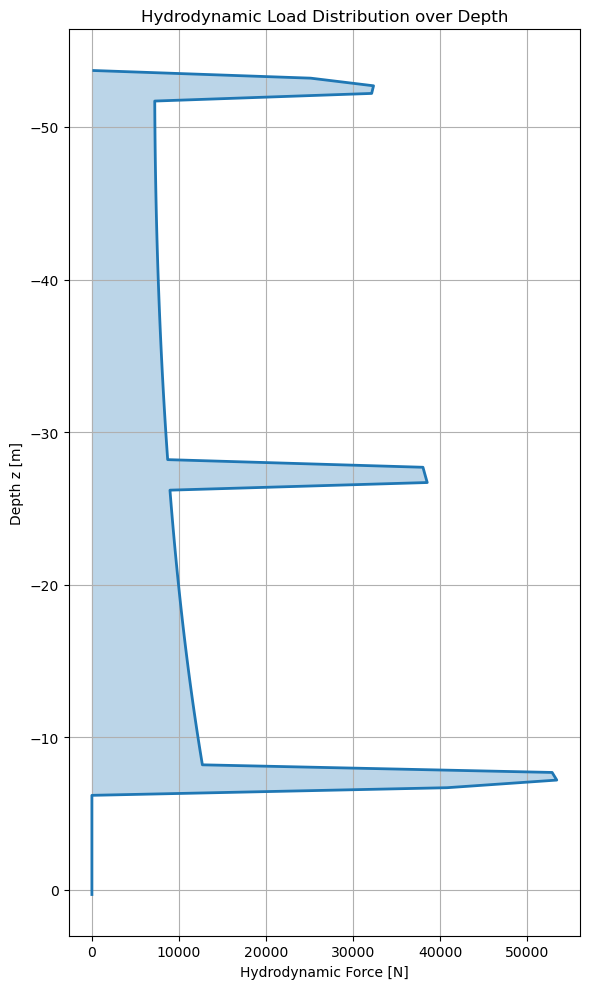

In [95]:
F_total,M_total,results = stick_model()

print("\n===== STICK MODEL RESULTS =====\n")
for r in results:
    print(f"Range {r['zU']:.3f} to {r['zL']:.3f} m")
    print(f"  Equivalent Drag Diameter  : {r['Dde']:.3f} m")
    print(f"  Equivalent Inertia Diam.  : {r['Die']:.3f} m")
    print(f"  Force in Range            : {r['Force']:.2f} N")
    print(f"  Moment about SWL          : {r['Moment_SWL']:.2f} Nm\n")
print("================================")
print(f"Total Base Shear  : {F_total:.2f} N")
print(f"Total Base Moment : {M_total:.2f} Nm")
print("================================\n")

force_distribution = hydrodynamic_distribution(nodes,members,H,T,h,phase=phase)

z_vals = [fd['z'] for fd in force_distribution]
forces = [fd['Force'] for fd in force_distribution]

plt.figure(figsize=(6,10))
plt.plot(forces,z_vals,linewidth=2)
plt.fill_betweenx(z_vals,0,forces,alpha=0.3)
plt.gca().invert_yaxis()   # Depth downward, SWL at top
plt.xlabel('Hydrodynamic Force [N]')
plt.ylabel('Depth z [m]')
plt.title('Hydrodynamic Load Distribution over Depth')
plt.grid(True)
plt.tight_layout()
plt.show()